Lingering questions:

    - How well is the warm start working?


In [1]:
import sys
# add path to gp-quadrature
sys.path.append('/Users/colecitrenbaum/Documents/GPs/gp-quadrature')
sys.path.append('/Users/colecitrenbaum/Documents/GPs/gp-quadrature/kernels')
from kernels import SquaredExponential
from vanilla_gp_sampling import sample_bernoulli_gp
from efgpnd import ToeplitzND, compute_convolution_vector_vectorized_dD
import time
import torch
from efgpnd import NUFFT
from cg import ConjugateGradients
from torch import vmap
# from PG_GP import *
from typing import Callable
from matplotlib import pyplot as plt

In [2]:
#default to float64
torch.set_default_dtype(torch.float64)

# --- Parameters ---
n = 1_000  # Number of points
d = 2 # Dimensionality of the input space
true_length_scale =.7
true_variance = 1
dtype = torch.float64  # Use float64 as in the original example
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
print(f"Using device: {device}")

# --- Generate Input Points ---
# Generate random points in d-dimensional space from -1 to 1
x = torch.rand(n, d, dtype=dtype, device=device) * 2 - 1
y,f = sample_bernoulli_gp(x,length_scale=true_length_scale,variance=true_variance)
rdtype = torch.float64
cdtype = torch.complex128
jitter = 1e-8


Using device: cpu


In [3]:
# define device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import torch
import torch.nn as nn
from typing import List, Iterator, Tuple, Optional, Union
from torch.optim import Adam
from utils.kernels import get_xis
import math



# Setup

In [5]:
class qVariationalParams(nn.Module):
    """Variational parameters for the Polyagamma GP."""
    def __init__(self, n, device=None, dtype=torch.float64):
        """
        Initialize variational parameters.
        
        Args:
            n: Number of data points
            device: torch device
            dtype: torch dtype
        """
        super().__init__()
        self.Delta = nn.Parameter(torch.full((n,), 0.25, dtype=dtype, device=device))
q = qVariationalParams(n)


# All the epsilons here

In [6]:
nufft_eps = 1e-7
cg_tol = 1e-6
eps = 1e-4
trunc_eps = 1e-4

In [7]:
rdtype = x.dtype
cdtype = torch.complex128

In [8]:
# kernel = SquaredExponential(dimension = d,init_lengthscale=.1,init_variance=.4)
kernel      = SquaredExponential(dimension=d,
                                    init_lengthscale=0.3,
                                    init_variance =1)
x       = x.to(device, rdtype)
data = x 
y       = y.to(device, rdtype)
if x.ndim == 1:
    x = x.unsqueeze(-1)


In [9]:
def setup_spectral_representation(x, kernel, eps, trunc_eps, device, rdtype, cdtype):
    x0 = x.min(dim=0).values  
    x1 = x.max(dim=0).values  

    if x.ndim == 1:
        x = x.unsqueeze(-1)
    d = x.shape[1]
    domain_lengths = x1 - x0
    L = domain_lengths.max()
    N = x.shape[0]
    xis_1d, h, mtot = get_xis(kernel_obj=kernel, eps=eps, L=L, use_integral=True, l2scaled=False,trunc_eps=trunc_eps)
    grids = torch.meshgrid(*(xis_1d for _ in range(d)), indexing='ij') # makes tensor product Jm 
    xis = torch.stack(grids, dim=-1).view(-1, d) 
    spec_density = kernel.spectral_density(xis).to(dtype=rdtype)
    # spec_density = torch.clamp(spec_density, min=1e-4)
    ws2 = spec_density * h**d
    ws2 = ws2.to(device=device, dtype=cdtype)
    ws = torch.sqrt(ws2) # (mtot**d,1)

    m_conv = (mtot - 1) // 2
    v_kernel = compute_convolution_vector_vectorized_dD(m_conv, x, h).to(dtype=cdtype)
    toeplitz = ToeplitzND(v_kernel, force_pow2=True)   
    spec_grad = kernel.spectral_grad(xis)
    Dprime  = (h**d * spec_grad).to(cdtype)  # (M, 3)
    
    
    return xis, h, mtot, ws, toeplitz, Dprime, spec_density, spec_grad

xis, h, mtot, ws, toeplitz, Dprime, spec_density, spec_grad = setup_spectral_representation(x, kernel, eps,trunc_eps, device, rdtype, cdtype)
ws2 = ws.pow(2)
delta = (q.Delta.to(dtype=cdtype, device=device)).clone()



In [10]:
def naive_kernel(x,xis):
    F_train = torch.exp(2 * math.pi * 1j * torch.matmul(x, xis.T)).to(cdtype)
    return F_train


In [11]:
# Create the NUFFT operator
OUT = (mtot,)*d
nufft_op = NUFFT(x, torch.zeros_like(x), h, nufft_eps, cdtype=cdtype, device=device)

# Define the simplified helper functions
fadj = lambda v: nufft_op.type1(v, out_shape=OUT).reshape(-1)    # F* apply: nonuniform → uniform
fwd = lambda fk: nufft_op.type2(fk, out_shape=OUT)         
fadj_batched = vmap(fadj, in_dims=0, out_dims=0)
fwd_batched = vmap(fwd, in_dims=0, out_dims=0)
fadj_b = fadj_batched       # F apply:  uniform → nonuniform

/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/torch/_tensor.py:1218: ComplexWarning: Casting complex values to real discards the imaginary part
  return self.numpy().astype(dtype, copy=False)


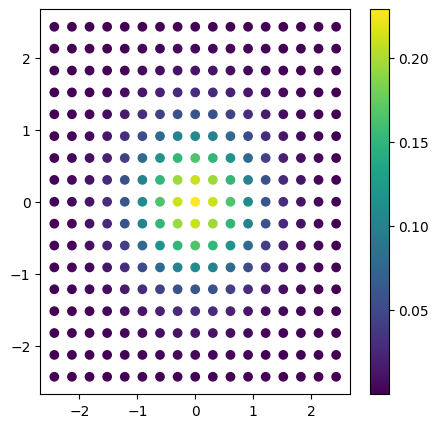

In [12]:
# plot ws in 2d wrt xis 
if d==2:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,5))
    plt.scatter(xis[:,0], xis[:,1], c=ws, cmap='viridis')
    plt.colorbar()
    plt.show()


In [13]:
def setup_sigma_solver(toeplitz, fadj_batched, fwd_batched, ws, ws2, xis=None):
    """
    Build a Σ·z matvec using Woodbury:
      Σ z = K z − K (I + ΔK)^{-1} Δ K z,
    with K = Ψ Ψ^*, Ψ = F diag(ws). We solve once in feature space:
      (I + Ψ^* Δ Ψ) x = Ψ^*(Δ K z), then Σ z = K z − Ψ x.

    Uses a Toeplitz warm-start: Ã = I + Δ̄ Ψ^*Ψ  ≈  I + Δ̄ (ws · T · ws).
    Prints warm-start and main CG iteration counts.
    """

    def Sigma_z_mm(
        z: torch.Tensor,
        delta_buf: torch.Tensor,
        fadj_batched=fadj_batched,
        fwd_batched=fwd_batched,
        ws: torch.Tensor = ws,
        ws2: torch.Tensor = ws2,
        cg_tol: float = 1e-6,
        vanilla: bool = True,  # kept for API-compat; ignored
    ) -> torch.Tensor:

        # ---- shapes ----
        vector_input = (z.dim() == 1)
        if vector_input:
            z = z.unsqueeze(0)                    # (B=1, n)

        Δ = delta_buf.view(1, -1).to(z)           # (B,n), broadcastable

        # ---- build RHS and K z ----
        z_feat = fadj_batched(z)                  # (B,M) = F^* z
        Kz     = fwd_batched(ws2 * z_feat)        # (B,n) = Ψ Ψ^* z

        s = ws * fadj_batched(Δ * Kz)             # (B,M) = Ψ^*(Δ K z)

        # ---- operators on feature space ----
        # A x = (I + Ψ^*ΔΨ) x
        def A_feat(u: torch.Tensor) -> torch.Tensor:
            psi_u = fwd_batched(ws * u)           # (B,n)
            return u + ws * fadj_batched(Δ * psi_u)

        # Ã x = (I + Δ̄ Ψ^*Ψ) x  ≈  u + Δ̄ (ws · T(ws ⊙ u))
        # (same warm-start as you used previously)
        Δbar = delta_buf.to(z).mean()
        def Atilde(u: torch.Tensor) -> torch.Tensor:
            if u.dim() == 1:
                return u + Δbar * (ws * toeplitz(ws * u))
            rows = [ws * toeplitz(ws * u[b]) for b in range(u.shape[0])]
            return u + Δbar * torch.stack(rows, dim=0)

        # ---- Toeplitz warm-start then main CG ----
        WARMSTART = True
        WARM_TOL  = 1e-3
        WARM_MAX  = 5000

        x0 = torch.zeros_like(s)
        if WARMSTART:
            cg0 = ConjugateGradients(Atilde, s, x0=torch.zeros_like(s),
                                     tol=WARM_TOL, max_iter=WARM_MAX,
                                     early_stopping=True)
            x_ws = cg0.solve()
            print(f"E-step warmstart (Toeplitz) iters: {cg0.iters_completed}")
            # If it stalled at max iters, fall back to zero init
            if cg0.iters_completed < 0.9 * WARM_MAX:
                x0 = x_ws
            else:
                print("E-step warmstart did not converge → zero init")

        cg  = ConjugateGradients(A_feat, s, x0=x0,
                                 tol=cg_tol, max_iter=2000,
                                 early_stopping=True)
        x = cg.solve()                            # (B,M)
        print(f"E-step CG (I+Ψ^*ΔΨ) iters: {cg.iters_completed}")

        # ---- assemble Σ z ----
        v = Kz - fwd_batched(ws * x)              # (B,n)
        if vector_input:
            v = v.squeeze(0)
        return v

    return Sigma_z_mm



In [14]:
def estep(
    y, q,
    max_iters=5, rho0=1.0, gamma=1e-3,
    tol=1e-4, verbose=True, J=5, cg_tol=1e-7,
    toeplitz=None, fadj_batched=None, fwd_batched=None, ws=None, ws2=None, xis=None,
    vanilla: bool = False,
    reuse_probes: bool = True,
):
    """
    PolyGamma-GP E-step using a SINGLE batched CG solve per outer iteration.
    We stack [y_center; probes] as rows and call Sigma_z_mm once.

    Updates q.Delta in-place. Can be run once (max_iters=1) or repeatedly.
    Returns (m, Sigma_diags, Sz, probes, q).
    """
    import time, math, torch

    device = y.device
    rdtype = y.dtype  # real dtype (float32/64)
    y_center = (y.to(device=device, dtype=rdtype) - 0.5)           # (n,)

    # Get the Σ·z matvec
    Sigma_z_mm = setup_sigma_solver(toeplitz, fadj_batched, fwd_batched, ws, ws2, xis=xis)

    # Pre-allocate probes; re-used across iterations if reuse_probes=True
    if J > 0:
        probes = torch.empty((J, y.numel()), device=device, dtype=rdtype)
    else:
        probes = torch.empty((0, y.numel()), device=device, dtype=rdtype)

    rhos = rho0 / (1 + gamma * torch.arange(max_iters, device=device, dtype=rdtype))

    with torch.no_grad():
        for it in range(max_iters):
            t_iter = time.time()

            # (Re)draw Rademacher probes unless we reuse the same ones
            if J > 0 and (it == 0 or not reuse_probes):
                probes.bernoulli_(0.5).mul_(2).sub_(1)            # ±1

            # -------- single batched Σ solve --------
            # Stack RHSs: first row is y_center; remaining are probes
            if J > 0:
                Z = torch.cat([y_center[None, :], probes], dim=0)  # (1+J, n)
            else:
                Z = y_center[None, :]                              # (1, n)

            t0 = time.time()
            S_all = Sigma_z_mm(                                    # (1+J, n)
                z=Z, delta_buf=q.Delta, cg_tol=cg_tol,
                fadj_batched=fadj_batched, fwd_batched=fwd_batched,
                ws=ws, ws2=ws2, vanilla=vanilla
            ).real
            t1 = time.time()

            # Split out mean and probe images
            m  = S_all[0]                                          # (n,)
            Sz = S_all[1:] if J > 0 else torch.empty_like(S_all[:0])

            if verbose:
                if J > 0:
                    print(f"Σ·[y_center & {J} probes] time: {t1 - t0:.3f}s")
                else:
                    print(f"Σ·y_center time: {t1 - t0:.3f}s")

            # Hutchinson diag estimate
            if J > 0:
                Sigma_diags = (probes * Sz).mean(dim=0).real       # (n,)
            else:
                # If J==0, skip trace-estimate; fall back to zeros (or add option for Lanczos)
                Sigma_diags = torch.zeros_like(m)

            # PG update
            c2     = (Sigma_diags + m.pow(2)).clamp(min=1e-12)
            c      = c2.sqrt()
            Lambda = torch.tanh(0.5 * c) / (2.0 * c)               # (n,)

            rho = float(rhos[it])
            q.Delta.mul_(1 - rho).add_(rho * Lambda)
            q.Delta.clamp_(min=0.0)

            resid = (q.Delta - Lambda).abs().max().item()
            if verbose:
                print(f"it {it:3d}  ρ={rho:.3f}  max|Δ−Λ|={resid:.3e}  time={time.time()-t_iter:.3f}s")
                # quick analytic accuracy readout
                denom = torch.sqrt(1.0 + (math.pi / 8.0) * Sigma_diags)
                p_hat = torch.sigmoid(m / denom)
                acc   = (p_hat.real.gt(0.5) == y).float().mean().item()
                print(f"predictive accuracy (analytic) = {acc:.6f}")

    return m, Sigma_diags, Sz, probes, q


In [15]:
Sigma_z_mm = setup_sigma_solver(toeplitz, fadj_batched, fwd_batched,ws,ws2,xis=xis)

z_test = torch.randn(n,device=device,dtype=cdtype)
sigma_z_test = Sigma_z_mm(z_test,q.Delta,fadj_batched,fwd_batched,ws,ws2,vanilla=False)




E-step warmstart (Toeplitz) iters: 12
E-step CG (I+Ψ^*ΔΨ) iters: 15


In [16]:
m, Sigma_diags, Sz, probes, q = estep(
    y, q,
    max_iters   = 1,
    rho0        = 0.7,
    gamma       = 1e-3,
    tol         = 1e-8,
    verbose     = True,
    J           = 10,
    cg_tol      = cg_tol,
    toeplitz=toeplitz,
    fadj_batched=fadj_batched,
    fwd_batched=fwd_batched,
    ws=ws,
    ws2=ws2,
    vanilla=True,
)


E-step warmstart (Toeplitz) iters: 12
E-step CG (I+Ψ^*ΔΨ) iters: 17
Σ·[y_center & 10 probes] time: 0.065s
it   0  ρ=0.700  max|Δ−Λ|=1.415e-02  time=0.065s
predictive accuracy (analytic) = 0.666000


In [ ]:
bigger_count = 0
smaller_count = 0
if n<2000:
    F_train = naive_kernel(x, xis)

# Numerically stable version using Cholesky solves and log-determinants
# if x.shape[0]<3000:
def compute_vanilla_gradient(x, y, m, kernel, ws, ws2, F_train, q, jitter=1e-8,Dprime=Dprime):
    """
    Compute vanilla gradient for GP classification using desnse approximated kernel matrix. Dense relative to quadrature kernel, but not the original kernel matrix.
    
    Args:
        x: input points (n, d)
        y: binary labels (n,)
        m: posterior mean (n,)
        kernel: kernel object with variance and lengthscale
        ws: weights (M,)
        ws2: squared weights (M,)
        F_train: feature matrix (n, M)
        q: variational parameters object
        jitter: numerical stability parameter
        
    Returns:
        tuple: (grad_var, grad_ls, elbo)
    """
    m = m.flatten()
    W_F_train_star = torch.diag(ws) @ F_train.conj().T
    K_train = (F_train * ws) @ W_F_train_star
    # print(K_train[0,0])
    
    num_iters = 20

    """
    Returns: (ELBO, grad_var, grad_ls)
    for GP classification ELBO under Poly-Gamma augmentation,
    with manual gradients for kernel.variance and kernel.lengthscale.
    """
    n = x.shape[0]
    device = x.device

    # 1) Precompute things that don't change in the loop
    kappa = y - 0.5                                 # (n,)
    # print(ws[0])
    Kff   = F_train @ (torch.diag(ws2.to(dtype=cdtype))) @ F_train.T.conj()
    Kff = Kff.real                     # (n,n)
    D2    = torch.cdist(x, x, p=2).pow(2)            # (n,n)

    # 2) PG variational parameter
    xi = torch.ones(n, device=device)
    m = m.unsqueeze(1).T

    # 3) Fixed-point updates for (m, S)
    for _ in range(1):
        omega = q.Delta

        # build K = Kff + jitter·I
        K = Kff + jitter * torch.eye(n, device=device)
        # print(Kff[0,0])
        try:
            L = torch.linalg.cholesky(K, upper=False)
        except RuntimeError:
            # fallback: add more jitter if not positive definite
            print("Fallback: adding more jitter")
            K = Kff + (jitter) * torch.eye(n, device=device)
            L = torch.linalg.cholesky(K, upper=False)

        # K⁻¹ via Cholesky (never invert directly)
        I = torch.eye(n, device=device,dtype=rdtype)
        K_inv = torch.cholesky_solve(I, L, upper=False)  # (n,n)

        # S⁻¹ = K⁻¹ + diag(ω)  ⇒  S = (S⁻¹)⁻¹
        S_inv = K_inv + torch.diag(omega)
        try:
            LS = torch.linalg.cholesky(S_inv, upper=False)
        except RuntimeError:
            # fallback: add more jitter if not positive definite
            print("Fallback LS: adding more jitter")
            S_inv = S_inv + (jitter * 10) * torch.eye(n, device=device)
            LS = torch.linalg.cholesky(S_inv, upper=False)
        S = torch.cholesky_inverse(LS, upper=False)  # (n,n)

        # 4) Compute ELBO = E_q[log p(y,f,ω)] − E_q[log q(f,ω)]
        # 4a) likelihood term
        elbo_lik = (kappa * m
                    - 0.5 * omega * (m ** 2 + torch.diagonal(S))
                    - torch.log(torch.tensor(2.0, device=device))).sum()

        # 4b) prior term (use logdet via Cholesky for stability)
        m_col = m.T
        Kinv_m = torch.cholesky_solve(m_col, L, upper=False).squeeze(-1)
        quad = (m * Kinv_m).sum()
        trace_S = torch.trace(torch.cholesky_solve(S, L, upper=False))
        logdet_K = 2.0 * torch.sum(torch.log(torch.diagonal(L)))
        elbo_prior = -0.5 * (quad + trace_S + logdet_K + n * math.log(2 * torch.pi))
        elbo = elbo_lik + elbo_prior

        # 5) Manual gradients
        var = kernel.variance
        ls = kernel.lengthscale

        # ∂K/∂var and ∂K/∂ls
        dK_dvar = F_train @ torch.diag(Dprime[:, 1].to(dtype=cdtype)) @ F_train.T.conj()
        dK_dls = F_train @ torch.diag(Dprime[:, 0].to(dtype=cdtype)) @ F_train.T.conj()

        # helper: v = K⁻¹ m
        v = torch.cholesky_solve(m_col, L, upper=False).squeeze(-1)

        # grad wrt variance
        dK_dvar_r = dK_dvar.to(dtype=rdtype)
        t1var = v @ (dK_dvar_r @ v)
        # Use trace identities for stability, avoid explicit K_inv
        # t2var = tr(K⁻¹ dK K⁻¹ S) = tr((K⁻¹ S) (K⁻¹ dK))
        KinvS = torch.cholesky_solve(S, L, upper=False)
        t2var = torch.sum(KinvS * (K_inv @ dK_dvar_r))
        t3var = torch.sum(K_inv * dK_dvar_r)
        grad_var = 0.5 * (t1var + t2var - t3var)

        # grad wrt lengthscale
        dK_dls_r = dK_dls.to(dtype=rdtype)
        t1 = v @ (dK_dls_r @ v)
        KinvS = torch.cholesky_solve(S, L, upper=False)
        t2 = torch.sum(KinvS * (K_inv @ dK_dls_r))
        t3 = torch.sum(K_inv * dK_dls_r)
        grad_ls = 0.5 * (t1 + t2 - t3)

    t1v1 = t1
    t2v1 = t2
    t3v1 = t3
    elbo1 = elbo
    print(jitter)
    return grad_var, grad_ls, elbo1, t1var, t2var, t3var, t1v1, t2v1, t3v1
if n<2000:
    # Call the function
    F_train = naive_kernel(x, xis)
    grad_var, grad_ls, elbo1, t1var, t2var, t3var, t1v1, t2v1, t3v1 = compute_vanilla_gradient(
    x, y, m, kernel, ws, ws2, F_train, q, jitter=1e-6)

    print('##Lengthscale##')
    print(f't1v1: {t1v1}, t2v1: {t2v1}, t3v1: {t3v1}')
    print('##Variance##')
    print(f't1v1: {t1var}, t2v1: {t2var}, t3v1: {t3var}')



1e-06
##Lengthscale##
t1v1: -130.63532713707144, t2v1: -6719.285877612467, t3v1: -6913.659332648385
##Variance##
t1v1: 16.559873761260768, t2v1: 158.46348207036021, t3v1: 188.57710368110565


/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_41454/2598822843.py:109: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:308.)
  dK_dvar_r = dK_dvar.to(dtype=rdtype)


# M Step

In [18]:
    kernel      = SquaredExponential(dimension=d,
                                    init_lengthscale=0.3,
                                    init_variance =1)
xis, h, mtot, ws, toeplitz, Dprime, spec_density, spec_grad = setup_spectral_representation(x, kernel, eps,trunc_eps, device, rdtype, cdtype)
ws2 = ws.pow(2)



# F_train = naive_kernel(x, xis)
# Kff   = F_train @ (torch.diag(ws2.to(dtype=cdtype))) @ F_train.T.conj()
# Kff = Kff.real.to(dtype=cdtype)                    # (n,n)

# 2) PG variational parameter

probes = torch.empty((10, n), device=device, dtype=rdtype)
probes.bernoulli_(0.5).mul_(2).sub_(1)  # ±1
probes = probes.to(dtype=cdtype)

mu = m
omega = q.Delta
D2 = ws2


# Term 1 Vanilla check

In [19]:


# import torch

# def gp_mstep_gradient_vanilla(F_train, D2, Dprime, omega, probes, mu=None):
#     device = F_train.device
#     # Choose complex dtype if any input is complex, else float64
#     cdtype = (torch.complex128
#               if (torch.is_complex(F_train) or torch.is_complex(D2) or torch.is_complex(Dprime))
#               else torch.float64)

#     F = F_train.to(cdtype)
#     D2 = D2.to(cdtype)                 # (M,)
#     if Dprime.ndim == 1:
#         Dprime = Dprime[:, None]       # (M,1)
#     Dprime = Dprime.to(cdtype)         # (M,P)
#     omega = omega.to(cdtype)           # (n,)
#     n, M = F.shape
#     P = Dprime.shape[1]

#     # Coerce probes to (B, n)
#     probes = probes.to(cdtype)
#     if probes.ndim == 1:
#         probes = probes[None, :]
#     B = probes.shape[0]

#     # --- Build dense K, Ω, A ---
#     # K = F diag(D2) F*
#     K = F @ torch.diag(D2) @ F.conj().T                     # (n,n)
#     Omega = torch.diag(omega)                               # (n,n)
#     A = torch.eye(n, dtype=cdtype, device=device) + Omega @ K  # (n,n)

#     # --- alpha = (A^{-1} probes^T)^T (rows are A^{-1} z_i) ---
#     A_inv = torch.linalg.inv(A)                             # (n,n)
#     alpha = (A_inv @ probes.T).T                            # (B,n)

#     # --------- TRACE TERM  T_p = tr( A^{-1} Ω ∂K_p )  ----------
#     # We'll compute bz_i,p = (Ω ∂K_p) z_i for all probes/params, then
#     # Hutch:  T_p ≈ (1/B) Σ_i z_i^T A^{-1} (Ω ∂K_p) z_i = (1/B) Σ_i alpha_i^T bz_i,p
#     #
#     # Precompute F*Z  once: S = F* Z^T has shape (M,B)
#     S = F.conj().T @ probes.T                               # (M,B)

#     # For each parameter p:
#     trace_est = torch.empty(P, dtype=torch.float64 if cdtype==torch.float64 else torch.float32, device=device)
#     for p in range(P):
#         # ∂K_p Z  = F diag(Dprime[:,p]) F* Z  = F ( diag(Dprime[:,p]) @ S )
#         tmp = torch.diag(Dprime[:, p]) @ S                  # (M,B)
#         dKZ = F @ tmp                                       # (n,B)
#         BZ = (Omega @ dKZ).T                                # (B,n)

#         # contraction: alpha_i^T (BZ)_i
#         vals = (alpha.conj() * BZ).sum(dim=1).real          # (B,)
#         trace_est[p] = vals.mean()

#     # Combined trace contribution to gradient:  -0.5 * T_p
#     grad_trace = -0.5 * trace_est                            # (P,)


#     return {
#         "K": K, "A": A, "A_inv": A_inv, "alpha": alpha,      # intermediates (for inspection)
#         "trace_est": trace_est, "grad_trace": grad_trace,    # trace pieces
#     }
# grad_out = gp_mstep_gradient_vanilla(F_train, D2, Dprime, omega, probes, mu)

# print(-grad_out['trace_est'])

In [20]:
def m_step_vanilla(F_train, D2, Dprime, omega, probes, *,
           cg_tol=1e-8, warmstart=False, warm_tol=1e-2, warm_maxit=5000):
    """
    Hutchinson estimate of z^T Ω F diag(D'_p) F^* (I + Ω K)^{-1} z
    with K = F diag(D2) F^*, using an SPD solve in feature space.

    Consolidation: solve (I+S) once for both term2 probes and term1's β_x,
    using β_x = (I + B D)^{-1} q_y.
    """
    import torch
    cdtype = (torch.complex128 if (torch.is_complex(F_train)
                                   or torch.is_complex(D2)
                                   or torch.is_complex(Dprime))
              else torch.float64)

    # --- Cast & shapes ---
    F = F_train.to(cdtype)
    n, M = F.shape
    D2 = D2.to(cdtype).flatten()
    if Dprime.ndim == 1: Dprime = Dprime[:, None]
    Dprime = Dprime.to(cdtype)
    omega = omega.to(cdtype).flatten()

    probes = probes.to(cdtype)
    if probes.ndim == 1: probes = probes[None, :]      # (B,n)

    # --- Helpers (Ω diagonal kept explicit) ---
    def apply_Omega(v):  # v: (n,) or (n,B)
        return (omega[:, None] * v) if v.ndim == 2 else (omega * v)

    # Safe sqrt / inverse sqrt of D (diag)
    D2_real = D2.real
    epsD = max(float(D2_real.mean()) * 1e-14, 1e-14)
    D2c = torch.clamp(D2_real, min=epsD).to(cdtype)
    Ds = torch.sqrt(D2c)                 # D^{1/2} (M,)
    Dsinv = 1.0 / Ds                     # D^{-1/2} (M,)

    # Diagonal(B) = diag(F^* Ω F) = Σ_n ω_n |F_{n,m}|^2
    diagB = (apply_Omega((F.conj()*F).real).sum(dim=0)).to(cdtype).real  # (M,)
    # Jacobi for I+S: diag(I+S) = 1 + diagB * D2
    diag_IpS = 1.0 + (diagB * D2c)
    def M_inv_IpS(X):
        if X.ndim == 1: return X / diag_IpS
        return X / diag_IpS[None, :]

    # ----- Operators -----
    # S y = D^{1/2} (F^* Ω F) D^{1/2} y
    def apply_S(Y):
        if Y.ndim == 1:
            t = Ds * Y                         # (M,)
            u = F @ t                          # (n,)
            u = apply_Omega(u)                 # (n,)
            v = F.conj().mT @ u                # (M,)
            return Ds * v                      # (M,)
        # batched (B,M)
        t = Y * Ds[None, :]                    # (B,M)
        u = (F @ t.T)                          # (n,B)
        u = apply_Omega(u)                     # (n,B)
        v = (F.conj().mT @ u)                  # (M,B)
        return (Ds[:, None] * v).T             # (B,M)

    def apply_IpS(Y):
        return Y + apply_S(Y)

    # ----- Toeplitz SPD warm start for (I+S) -----
    # Use B ≈ w̄ T  ⇒  S ≈ w̄ D^{1/2} T D^{1/2}
    wbar = omega.real.mean().to(cdtype)

    def apply_IpS_toeplitz(Y):
        if Y.ndim == 1:
            t = Ds * Y
            return Y + wbar * (Ds * toeplitz(t))
        t = Y * Ds[None, :]
        rows = [toeplitz(t[b]) for b in range(t.shape[0])]
        Tt = torch.stack(rows, dim=0)          # (B,M)
        return Y + wbar * (Ds[None, :] * Tt)

    # Small safe warm start wrapper
    def warm_solve_IpS(rhs):
        y0 = torch.zeros_like(rhs)
        if not warmstart: return y0
        cg0 = ConjugateGradients(apply_IpS_toeplitz, rhs, x0=y0,
                                 tol=warm_tol, max_iter=warm_maxit,
                                 early_stopping=True)
        y_ws = cg0.solve()
        # if it clearly didn't move, drop the warm start
        if cg0.iters_completed < 0.9*warm_maxit:
            print(f'warmstart iters: {cg0.iters_completed}')
            return y_ws
        else:
            print('warmstart did not converge')
            return y0

    # ----- Solve helper: (I+S) y = D^{1/2} q  ;  β = D^{-1/2} y -----
    def solve_A_beta(q):  # q: (M,) or (B,M)
        rhs = (Ds * q) if q.ndim == 1 else (q * Ds[None, :])
        y0  = warm_solve_IpS(rhs)
        cg  = ConjugateGradients(apply_IpS, rhs, x0=y0, tol=cg_tol,
                                 max_iter=2000, early_stopping=True,
                                 M_inv_apply=M_inv_IpS)
        y = cg.solve()
        if q.ndim == 1:
            beta = Dsinv * y
        else:
            beta = y * Dsinv[None, :]
        return beta, cg.iters_completed

    # ==================== Build RHSs ONCE & solve together ====================
    # term2 probes: q_b = F^* z_b
    Q_block = (F.conj().mT @ probes.mT).T           # (B,M)

    # term1 uses β_x = (I + B D)^{-1} q_y  (no need to form B D q_y)
    y_tilde = (y.to(cdtype) - 0.5)                  # assumes `y` in scope
    q_y     = F.conj().mT @ y_tilde                 # (M,)

    # stack all RHSs and do a single batched solve
    Q_all   = torch.cat([Q_block, q_y[None, :]], dim=0)   # (B+1, M)
    Beta_all_BM, it_all = solve_A_beta(Q_all)             # (B+1, M)

    # unpack
    Beta_BM = Beta_all_BM[:-1, :]                         # (B, M)
    beta_x  = Beta_all_BM[-1, :]                          # (M,)
    Beta    = Beta_BM.T                                   # (M, B)

    # ==================== Hutchinson contraction (term 2) ====================
    Rfeat = (F.conj().mT @ (apply_Omega(probes.mT))).to(cdtype)  # (M,B) = F^* Ω z
    X     = (Rfeat.conj() * Beta)                                 # (M,B)
    vals  = (X.mT @ Dprime).real                                  # (B,P)
    T_hat = vals.mean(dim=0)                                      # (P,)

    # ==================== Term 1 from β_x ====================
    abs2   = (beta_x.conj() * beta_x).real                        # (M,)
    term1  = (Dprime.to(abs2.dtype).T @ abs2)                     # (P,)

    print(f"single CG (SPD) iters (all RHS): {it_all}")

    return {
        "term2": T_hat,
        "B": F.conj().mT @ (apply_Omega(F)),   # (M,M) if you still want it
        "Q": Q_block, "Beta": Beta, "R": Rfeat, "vals": vals,
        "term1": term1
    }




# CG gradients, trace approx

# rewrite as a hermitian system 

In [21]:
def m_step(fwd_batched, fadj_batched,D2, Dprime, omega, probes, *,
           cg_tol=1e-8, warmstart=False, warm_tol=1e-2, warm_maxit=5000):
    """
    Hutchinson estimate of z^T Ω F diag(D'_p) F^* (I + Ω K)^{-1} z
    with K = F diag(D2) F^*, using an SPD solve in feature space.

    Consolidation: solve (I+S) once for both term2 probes and term1's β_x,
    using β_x = (I + B D)^{-1} q_y.
    """
    import torch
    cdtype = torch.complex128

    # --- Cast & shapes ---
    # F = F_train.to(cdtype)
    n = omega.shape[0]
    M = D2.shape[0]
    # n, M = F.shape
    D2 = D2.to(cdtype).flatten()
    if Dprime.ndim == 1: Dprime = Dprime[:, None]
    Dprime = Dprime.to(cdtype)
    omega = omega.to(cdtype).flatten()

    probes = probes.to(cdtype)
    if probes.ndim == 1: probes = probes[None, :]      # (B,n)

    # --- Helpers (Ω diagonal kept explicit) ---
    def apply_Omega(v):  # v: (n,) or (n,B)
        return (omega[:, None] * v) if v.ndim == 2 else (omega * v)

    # Safe sqrt / inverse sqrt of D (diag)
    D2_real = D2.real
    epsD = max(float(D2_real.mean()) * 1e-14, 1e-14)
    D2c = torch.clamp(D2_real, min=epsD).to(cdtype)
    Ds = torch.sqrt(D2c)                 # D^{1/2} (M,)
    Dsinv = 1.0 / Ds                     # D^{-1/2} (M,)


    # ----- Operators -----
    # S y = D^{1/2} (F^* Ω F) D^{1/2} y
    def apply_S(Y):

        # batched (B,M)
        t = Y * Ds[None, :]                    # (B,M)
        u = fwd_batched(t).mT
        u = apply_Omega(u)                     # (n,B)
        v = fadj_batched(u.T).T
        return (Ds[:, None] * v).T             # (B,M)

    def apply_IpS(Y):
        return Y + apply_S(Y)

    # ----- Toeplitz SPD warm start for (I+S) -----
    # Use B ≈ w̄ T  ⇒  S ≈ w̄ D^{1/2} T D^{1/2}
    wbar = omega.real.mean().to(cdtype)

    def apply_IpS_toeplitz(Y):
        if Y.ndim == 1:
            t = Ds * Y
            return Y + wbar * (Ds * toeplitz(t))
        t = Y * Ds[None, :]
        rows = [toeplitz(t[b]) for b in range(t.shape[0])]
        Tt = torch.stack(rows, dim=0)          # (B,M)
        return Y + wbar * (Ds[None, :] * Tt)

    # Small safe warm start wrapper
    def warm_solve_IpS(rhs):
        y0 = torch.zeros_like(rhs)
        if not warmstart: return y0
        cg0 = ConjugateGradients(apply_IpS_toeplitz, rhs, x0=y0,
                                 tol=warm_tol, max_iter=warm_maxit,
                                 early_stopping=True)
        y_ws = cg0.solve()
        # if it clearly didn't move, drop the warm start
        if cg0.iters_completed < 0.9*warm_maxit:
            print(f'warmstart iters: {cg0.iters_completed}')
            return y_ws
        else:
            print('warmstart did not converge')
            return y0

    # ----- Solve helper: (I+S) y = D^{1/2} q  ;  β = D^{-1/2} y -----
    def solve_A_beta(q):  # q: (M,) or (B,M)
        rhs = (Ds * q) if q.ndim == 1 else (q * Ds[None, :])
        y0  = warm_solve_IpS(rhs)
        cg  = ConjugateGradients(apply_IpS, rhs, x0=y0, tol=cg_tol,
                                 max_iter=2000, early_stopping=True,)
                                #  M_inv_apply=M_inv_IpS)
        y = cg.solve()
        if q.ndim == 1:
            beta = Dsinv * y
        else:
            beta = y * Dsinv[None, :]
        return beta, cg.iters_completed

    # ==================== Build RHSs ONCE & solve together ====================
    # term2 probes: q_b = F^* z_b
    # Q_block = (F.conj().mT @ probes.mT).T           # (B,M)
    Q_block = fadj_batched(probes)

    # term1 uses β_x = (I + B D)^{-1} q_y  (no need to form B D q_y)
    y_tilde = (y.to(cdtype) - 0.5)                  # assumes `y` in scope
    # q_y     = F.conj().mT @ y_tilde                 # (M,)
    q_y = fadj_batched(y_tilde.unsqueeze(0))

    # stack all RHSs and do a single batched solve
    Q_all   = torch.cat([Q_block, q_y], dim=0)   # (B+1, M)
    Beta_all_BM, it_all = solve_A_beta(Q_all)             # (B+1, M)

    # unpack
    Beta_BM = Beta_all_BM[:-1, :]                         # (B, M)
    beta_x  = Beta_all_BM[-1, :]                          # (M,)
    Beta    = Beta_BM.T                                   # (M, B)

    # ==================== Hutchinson contraction (term 2) ====================
    # Rfeat = (F.conj().mT @ (apply_Omega(probes.mT))).to(cdtype)  # (M,B) = F^* Ω z
    Rfeat = fadj_batched(apply_Omega(probes.mT).T).T
    X     = (Rfeat.conj() * Beta)                                 # (M,B)
    vals  = (X.mT @ Dprime).real                                  # (B,P)
    T_hat = vals.mean(dim=0)                                      # (P,)

    # ==================== Term 1 from β_x ====================
    abs2   = (beta_x.conj() * beta_x).real                        # (M,)
    term1  = (Dprime.to(abs2.dtype).T @ abs2)                     # (P,)

    print(f"single CG (SPD) iters (all RHS): {it_all}")

    return {
        "term2": T_hat,
        # "B": F.conj().mT @ (apply_Omega(F)),   # (M,M) if you still want it
        "Q": Q_block, "Beta": Beta, "R": Rfeat, "vals": vals,
        "term1": term1
    }





out = m_step(fwd_batched, fadj_batched,D2, Dprime, omega, probes,warmstart=True)

term2 = out['term2'].detach().cpu().numpy()
print(f'term2: {term2}','term1: ',out['term1'].detach().cpu().numpy())
term1 = out['term1']
grad = 0.5*(term1 - term2)
print(f'my grad: {grad}')
# if grad_ls is in scope, print it
if 'grad_ls' in locals():
    print(f'ground truth grad: {grad_ls}, {grad_var}')

warmstart iters: 13
single CG (SPD) iters (all RHS): 29
term2: [-175.70489267   28.13081488] term1:  [-135.25488252   18.06725713]
my grad: tensor([20.2250, -5.0318])
ground truth grad: 31.869063949423435, -6.776873924742333


/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_41454/4065597661.py:143: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  grad = 0.5*(term1 - term2)


warmstart iters: 13
single CG (SPD) iters (all RHS): 29
warmstart iters: 12
single CG (SPD) iters (all RHS): 29
warmstart iters: 13
single CG (SPD) iters (all RHS): 29
warmstart iters: 13
single CG (SPD) iters (all RHS): 29
warmstart iters: 13
single CG (SPD) iters (all RHS): 29
warmstart iters: 13
single CG (SPD) iters (all RHS): 29
warmstart iters: 13
single CG (SPD) iters (all RHS): 29
warmstart iters: 12
single CG (SPD) iters (all RHS): 29
warmstart iters: 13
single CG (SPD) iters (all RHS): 29
warmstart iters: 13
single CG (SPD) iters (all RHS): 29


/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_41454/355205680.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([vals_arr[:,0], vals_arr[:,1]], positions=[1,2], labels=['length scale', 'variance'], patch_artist=True)


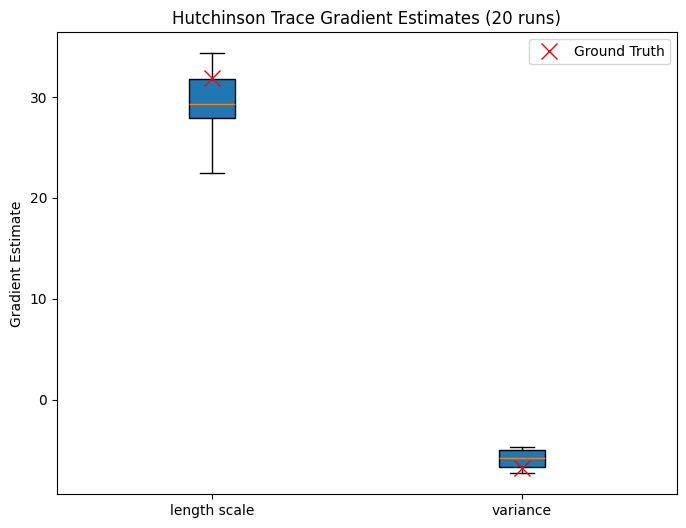

In [22]:
import matplotlib.pyplot as plt
import numpy as np
num_runs = 10
grads_list = []

for _ in range(num_runs):
    probes = torch.empty((10, n), device=device, dtype=rdtype)
    probes.bernoulli_(0.5).mul_(2).sub_(1)  # ±1
    probes = probes.to(dtype=cdtype)
    # out = m_step(F_train, D2, Dprime, omega, probes)
    out = m_step(fwd_batched, fadj_batched,D2, Dprime, omega, probes,warmstart=True)

    grad = 0.5*term1 - 0.5*(out['term2'])
    grads_list.append(grad.cpu().detach().numpy())

vals_arr = np.stack(grads_list)  # shape (num_runs, 2) for [ls, var]

fig, ax = plt.subplots(figsize=(8, 6))
box = ax.boxplot([vals_arr[:,0], vals_arr[:,1]], positions=[1,2], labels=['length scale', 'variance'], patch_artist=True)

# Mark ground truth values with an 'x'
# Use ax.plot instead of scatter to ensure both points are visible
if 'grad_ls' in locals():
    ax.plot([1, 2], [grad_ls.detach().cpu().numpy(), grad_var.detach().cpu().numpy()],
            color='red', marker='x', linestyle='None', markersize=12, label='Ground Truth')

ax.set_ylabel('Gradient Estimate')
ax.set_title('Hutchinson Trace Gradient Estimates (20 runs)')
ax.legend()
plt.show()


In [23]:

    # ----- set up ----------------------------------------------------------
    cg_tol      = 1e-6
    eps = 1e-4
    trunc_eps = 1e-4
    nufft_eps   = 1e-7

    ## kernels 
    kernel      = SquaredExponential(dimension=d,
                                    init_lengthscale=0.3,
                                    init_variance =1)


    # smaller LR, maximise=True
    optimizer   = torch.optim.Adam(kernel._gp_params_ref.parameters(),
                                
                                lr=0.05,
                                maximize=True)


    # one‑off: clear any momentum that came from earlier opposite‑sign runs
    for st in optimizer.state.values():
        st['exp_avg'].zero_();  st['exp_avg_sq'].zero_()



    lengthscales= []
    variances= []

    q = qVariationalParams(n)
    # ----- training loop ---------------------------------------------------
    for outer in range(50):                     # “epoch” index
        lengthscales.append(kernel.lengthscale)
        variances.append(kernel.variance)

        # -------- E–STEP (natural gradient) -------------------------------
        # -------- single M–STEP -------------------------------------------
        xis, h, mtot, ws, toeplitz, Dprime, spec_density, spec_grad = setup_spectral_representation(
            x, kernel, eps, trunc_eps,device, rdtype, cdtype)
        ws2        = ws.pow(2)

        # FstarKinv = Fstar_Kinv_z_local



        OUT        = (mtot,)*d
        nufft_op   = NUFFT(x, torch.zeros_like(x), h, nufft_eps,
                        cdtype=cdtype, device=device)

        fadj       = lambda v: nufft_op.type1(v, out_shape=OUT).reshape(-1)
        fwd        = lambda fk: nufft_op.type2(fk, out_shape=OUT)
        fadj_batched = vmap(fadj, in_dims=0, out_dims=0)
        fwd_batched = vmap(fwd, in_dims=0, out_dims=0)



        # F_train = naive_kernel(x, xis)
        m, Sigma_diags, Sz, probes, q = estep(
            y, q,
            max_iters   = 1,
            rho0        = 0.7,
            gamma       = 1e-3,
            tol         = 1e-6,
            verbose     = (outer == 0 or outer == 49),  # True for first and last iteration
            J           = 10,
            cg_tol      = cg_tol,
            toeplitz=toeplitz,
            fadj_batched=fadj_batched,
            fwd_batched=fwd_batched,
            ws=ws,
            ws2=ws2,
            xis=xis,
            vanilla = True
        )
        
        
        probes = torch.empty((10, n), device=device, dtype=rdtype)
        probes.bernoulli_(0.5).mul_(2).sub_(1)  # ±1
        probes = probes.to(dtype=cdtype)

        mu = m
        omega = q.Delta
        D2 = ws2


        out = m_step(fwd_batched, fadj_batched,D2, Dprime, omega, probes,cg_tol=1e-6,warmstart=True)
        grad_m = 0.5 * (out['term1'] - out['term2'])          # ∂ELBO/∂[ℓ, σ²]
        grad_m = grad_m.real





        # -------- apply gradient to raw params ----------------------------
        raw        = kernel._gp_params_ref.raw           # unconstrained vector
        pos        = kernel.lengthscale                  # because exp‑transform ⇒ dℓ/draw = ℓ
        raw.grad   = torch.stack([ grad_m[0] * pos,      # length‑scale component
                                grad_m[1] * kernel.variance , torch.tensor(0)])   # variance
        


        optimizer.step();  



        # d()
        # print(f"iter {outer:3d} | Our Method: ℓ = {kernel.lengthscale:.5f}, σ² = {kernel.variance:.5f} | grad = {grad_m[0].item():+.3e} ")
        # print(f'Term2: {term2[0]}, manual: {t2v1}', 'Term3: ', term3[0], 'manual: ', t3v1)

        print(f"iter {outer:3d} | Our Method: ℓ = {kernel.lengthscale:.5f}, σ² = {kernel.variance:.5f} | grad = {grad_m[0].item():+.3e} ")


E-step warmstart (Toeplitz) iters: 13
E-step CG (I+Ψ^*ΔΨ) iters: 17
Σ·[y_center & 10 probes] time: 0.063s
it   0  ρ=0.700  max|Δ−Λ|=1.392e-02  time=0.063s
predictive accuracy (analytic) = 0.666000
warmstart iters: 13
single CG (SPD) iters (all RHS): 21
iter   0 | Our Method: ℓ = 0.31538, σ² = 0.95123 | grad = +1.823e+01 
E-step warmstart (Toeplitz) iters: 13
E-step CG (I+Ψ^*ΔΨ) iters: 19
warmstart iters: 12
single CG (SPD) iters (all RHS): 21
iter   1 | Our Method: ℓ = 0.33107, σ² = 0.90478 | grad = +3.281e+01 
E-step warmstart (Toeplitz) iters: 12
E-step CG (I+Ψ^*ΔΨ) iters: 19
warmstart iters: 13
single CG (SPD) iters (all RHS): 21
iter   2 | Our Method: ℓ = 0.34775, σ² = 0.86078 | grad = +2.601e+01 
E-step warmstart (Toeplitz) iters: 12
E-step CG (I+Ψ^*ΔΨ) iters: 19
warmstart iters: 12
single CG (SPD) iters (all RHS): 20
iter   3 | Our Method: ℓ = 0.36474, σ² = 0.82055 | grad = +1.496e+01 
E-step warmstart (Toeplitz) iters: 11
E-step CG (I+Ψ^*ΔΨ) iters: 19
warmstart iters: 13
single 

In [24]:
lengthscales_vanilla = []
variances_vanilla = []
if n<3000:
    # ----- set up ----------------------------------------------------------
    cg_tol      = 1e-6
    eps = 1e-6
    trunc_eps = 1e-6
    nufft_eps   = 1e-7

    ## kernels 
    kernel      = SquaredExponential(dimension=d,
                                    init_lengthscale=0.3,
                                    init_variance =1)
    kernel_vanilla = SquaredExponential(dimension=d,
                                    init_lengthscale=.3,
                                    init_variance =1)

    # smaller LR, maximise=True
    optimizer   = torch.optim.Adam(kernel._gp_params_ref.parameters(),
                                
                                lr=0.05,
                                maximize=True)
    optimizer_vanilla   = torch.optim.Adam(kernel_vanilla._gp_params_ref.parameters(),
                                lr=0.05, 
                                maximize=True)

    # one‑off: clear any momentum that came from earlier opposite‑sign runs
    for st in optimizer.state.values():
        st['exp_avg'].zero_();  st['exp_avg_sq'].zero_()
    for st in optimizer_vanilla.state.values():
        st['exp_avg'].zero_();  st['exp_avg_sq'].zero_()


    lengthscales= []
    variances= []
    lengthscales_vanilla= []
    variances_vanilla= []
    q = qVariationalParams(n)
    q_vanilla = qVariationalParams(n)
    # ----- training loop ---------------------------------------------------
    for outer in range(50):                     # “epoch” index
        lengthscales.append(kernel.lengthscale)
        variances.append(kernel.variance)
        lengthscales_vanilla.append(kernel_vanilla.lengthscale)
        variances_vanilla.append(kernel_vanilla.variance)
        # -------- E–STEP (natural gradient) -------------------------------
        # -------- single M–STEP -------------------------------------------
        xis, h, mtot, ws, toeplitz, Dprime, spec_density, spec_grad = setup_spectral_representation(
            x, kernel, eps, trunc_eps,device, rdtype, cdtype)
        ws2        = ws.pow(2)

        # FstarKinv = Fstar_Kinv_z_local



        OUT        = (mtot,)*d
        nufft_op   = NUFFT(x, torch.zeros_like(x), h, nufft_eps,
                        cdtype=cdtype, device=device)

        fadj       = lambda v: nufft_op.type1(v, out_shape=OUT).reshape(-1)
        fwd        = lambda fk: nufft_op.type2(fk, out_shape=OUT)
        fadj_batched = vmap(fadj, in_dims=0, out_dims=0)
        fwd_batched = vmap(fwd, in_dims=0, out_dims=0)



        F_train = naive_kernel(x, xis)
        m, Sigma_diags, Sz, probes, q = estep(
            y, q,
            max_iters   = 1,
            rho0        = 0.7,
            gamma       = 1e-3,
            tol         = 1e-6,
            verbose     = (outer == 0 or outer == 49),  # True for first and last iteration
            J           = 10,
            cg_tol      = cg_tol,
            toeplitz=toeplitz,
            fadj_batched=fadj_batched,
            fwd_batched=fwd_batched,
            ws=ws,
            ws2=ws2,
            xis=xis,
            vanilla = True
        )
        


        xis_vanilla, h_vanilla, mtot_vanilla, ws_vanilla, toeplitz_vanilla, Dprime_vanilla, spec_density_vanilla, spec_grad_vanilla = setup_spectral_representation(
            x, kernel_vanilla, eps, trunc_eps,device, rdtype, cdtype)
        ws2_vanilla = ws_vanilla.pow(2)

        OUT_vanilla        = (mtot_vanilla,)*d

        nufft_op_vanilla   = NUFFT(x, torch.zeros_like(x), h_vanilla, nufft_eps,
                        cdtype=cdtype, device=device)
        fadj_vanilla       = lambda v: nufft_op_vanilla.type1(v, out_shape=OUT_vanilla).reshape(-1)
        fwd_vanilla        = lambda fk: nufft_op_vanilla.type2(fk, out_shape=OUT_vanilla)
        fadj_batched_vanilla = vmap(fadj_vanilla, in_dims=0, out_dims=0)
        fwd_batched_vanilla = vmap(fwd_vanilla, in_dims=0, out_dims=0)
        F_train = naive_kernel(x, xis_vanilla)

        m_vanilla, Sigma_diags_vanilla, Sz_vanilla, probes_vanilla, q_vanilla = estep(
            y, q_vanilla,
            max_iters   = 1,
            rho0        = 0.7,
            gamma       = 1e-3,
            tol         = 1e-6,
            verbose     = (outer == 0 or outer == 49),  # True for first and last iteration
            J           = 10,
            cg_tol      = cg_tol,
            toeplitz=toeplitz_vanilla,
            fadj_batched=fadj_batched_vanilla,
            fwd_batched=fwd_batched_vanilla,
            ws=ws_vanilla,
            ws2=ws2_vanilla,
            xis=xis_vanilla,
            vanilla = True
        )


        # F_train = naive_kernel(x, xis)
        # Kff   = F_train @ (torch.diag(ws2.to(dtype=cdtype))) @ F_train.T.conj()
        # Kff = Kff.real.to(dtype=cdtype)                    # (n,n)

        # 2) PG variational parameter
        # set random seed
        # torch.manual_seed(0)
        
        probes = torch.empty((50, n), device=device, dtype=rdtype)
        probes.bernoulli_(0.5).mul_(2).sub_(1)  # ±1
        probes = probes.to(dtype=cdtype)

        mu = m
        omega = q.Delta
        D2 = ws2


    ####### M STEP ##### 
        # out = m_step(F_train, D2, Dprime, omega, probes,cg_tol=1e-6,warmstart=True)
        out = m_step(fwd_batched, fadj_batched,D2, Dprime, omega, probes,cg_tol=1e-6,warmstart=True)
        grad_m = 0.5 * (out['term1'] - out['term2'])          # ∂ELBO/∂[ℓ, σ²]
        grad_m = grad_m.real
        # if grad_m[0].abs() > 1e2 and outer>2:
        #     print(f'hypers: {kernel.lengthscale}, {kernel.variance}')
        #     print(f'grad: {grad_m}')
        #     print('whats going on here')
        #     break


        F_train = naive_kernel(x, xis_vanilla)
    

        grad_var, grad_ls, elbo1, t1var, t2var, t3var, t1v1, t2v1, t3v1 = compute_vanilla_gradient(
        x, y, m_vanilla, kernel_vanilla, ws_vanilla, ws2_vanilla, F_train, q_vanilla,Dprime=Dprime_vanilla, jitter=1e-6
    )
        grad_vanilla= torch.hstack([grad_ls,grad_var,torch.tensor(0)]) 



        # -------- apply gradient to raw params ----------------------------
        raw        = kernel._gp_params_ref.raw           # unconstrained vector
        pos        = kernel.lengthscale                  # because exp‑transform ⇒ dℓ/draw = ℓ
        raw.grad   = torch.stack([ grad_m[0] * pos,      # length‑scale component
                                grad_m[1] * kernel.variance , torch.tensor(0)])   # variance
        


        raw_vanilla        = kernel_vanilla._gp_params_ref.raw           # unconstrained vector
        pos_vanilla        = kernel_vanilla.lengthscale                  # because exp‑transform ⇒ dℓ/draw = ℓ
        raw_vanilla.grad   = torch.stack([ grad_vanilla[0] * pos_vanilla,      # length‑scale component
                                grad_vanilla[1] * kernel_vanilla.variance , torch.tensor(0)])   # variance

        optimizer.step();     optimizer.zero_grad()



        optimizer_vanilla.step(); optimizer_vanilla.zero_grad()
        # d()
        # print(f"iter {outer:3d} | Our Method: ℓ = {kernel.lengthscale:.5f}, σ² = {kernel.variance:.5f} | grad = {grad_m[0].item():+.3e} ")
        # print(f'Term2: {term2[0]}, manual: {t2v1}', 'Term3: ', term3[0], 'manual: ', t3v1)

        print(f"iter {outer:3d} | Our Method: ℓ = {kernel.lengthscale:.5f}, σ² = {kernel.variance:.5f} | grad = {grad_m[0].item():+.3e} | Vanilla GP: ℓ = {kernel_vanilla.lengthscale:.5f}, σ² = {kernel_vanilla.variance:.5f} | grad = {grad_vanilla[0].item():+.3e}")


E-step warmstart (Toeplitz) iters: 12
E-step CG (I+Ψ^*ΔΨ) iters: 16
Σ·[y_center & 10 probes] time: 0.066s
it   0  ρ=0.700  max|Δ−Λ|=1.334e-02  time=0.066s
predictive accuracy (analytic) = 0.666000
E-step warmstart (Toeplitz) iters: 13
E-step CG (I+Ψ^*ΔΨ) iters: 17
Σ·[y_center & 10 probes] time: 0.069s
it   0  ρ=0.700  max|Δ−Λ|=1.303e-02  time=0.069s
predictive accuracy (analytic) = 0.666000
warmstart iters: 13
single CG (SPD) iters (all RHS): 21
1e-06
iter   0 | Our Method: ℓ = 0.31538, σ² = 0.95123 | grad = +2.585e+01 | Vanilla GP: ℓ = 0.31538, σ² = 0.95123 | grad = +2.896e+01
E-step warmstart (Toeplitz) iters: 12
E-step CG (I+Ψ^*ΔΨ) iters: 19
E-step warmstart (Toeplitz) iters: 12
E-step CG (I+Ψ^*ΔΨ) iters: 19
warmstart iters: 13
single CG (SPD) iters (all RHS): 21
1e-06
iter   1 | Our Method: ℓ = 0.33147, σ² = 0.90492 | grad = +2.176e+01 | Vanilla GP: ℓ = 0.33153, σ² = 0.90533 | grad = +2.632e+01
E-step warmstart (Toeplitz) iters: 13
E-step CG (I+Ψ^*ΔΨ) iters: 20
E-step warmstart (To

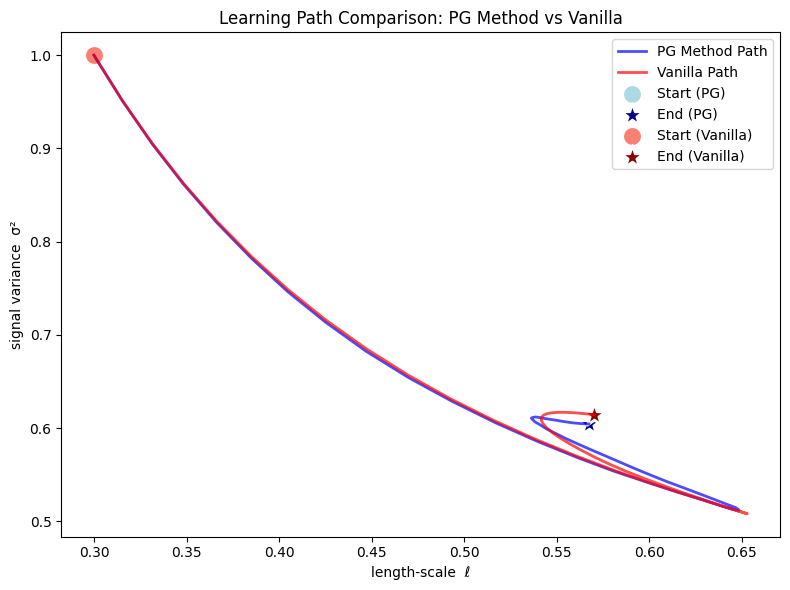

In [25]:
# if n<2000:
# Create a new figure for comparing learning paths
fig, ax = plt.subplots(figsize=(8, 6))
if lengthscales_vanilla is None:
    lengthscales_vanilla = []
    variances_vanilla = []

# Plot our method's path
ax.plot(lengthscales, variances, 'b-', linewidth=2, alpha=0.7, label='PG Method Path')

# Plot vanilla method's path
ax.plot(lengthscales_vanilla, variances_vanilla, 'r-', linewidth=2, alpha=0.7, label='Vanilla Path')

# Mark start/end points for our method
ax.scatter(lengthscales[0], variances[0],
        color='lightblue', 
        marker='o',
        s=200,
        label='Start (PG)',
        edgecolor='white',
        linewidth=2)

ax.scatter(lengthscales[-1], variances[-1],
        color='darkblue',
        marker='*', 
        s=300,
        label='End (PG)',
        edgecolor='white',
        linewidth=2)

# Set axes appropriately for the data
all_lengthscales = list(lengthscales) + list(lengthscales_vanilla)
all_variances = list(variances) + list(variances_vanilla)
if len(all_lengthscales) > 0 and len(all_variances) > 0:
    min_ls = min(all_lengthscales)
    max_ls = max(all_lengthscales)
    min_var = min(all_variances)
    max_var = max(all_variances)
    # Add a small margin
    margin_ls = 0.05 * (max_ls - min_ls) if max_ls > min_ls else 0.1
    margin_var = 0.05 * (max_var - min_var) if max_var > min_var else 0.1
    ax.set_xlim(min_ls - margin_ls, max_ls + margin_ls)
    ax.set_ylim(min_var - margin_var, max_var + margin_var)
else:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 3)

# Mark start/end points for vanilla method
if len(lengthscales_vanilla)>0:
    ax.scatter(lengthscales_vanilla[0], variances_vanilla[0],
            color='salmon',
            marker='o',
            s=200, 
            label='Start (Vanilla)',
            edgecolor='white',
            linewidth=2)

    ax.scatter(lengthscales_vanilla[-1], variances_vanilla[-1],
            color='darkred',
            marker='*',
            s=300,
            label='End (Vanilla)',
            edgecolor='white', 
            linewidth=2)

ax.set_xlabel("length‑scale  ℓ")
ax.set_ylabel("signal variance  σ²")
ax.set_title("Learning Path Comparison: PG Method vs Vanilla")
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
    from sklearn.gaussian_process import GaussianProcessClassifier
    from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
    import numpy as np, matplotlib.pyplot as plt


    # --- hyper‑parameter grid ----------------------------------------------------
    lengthscale_range = np.linspace(0.01, 1.0, 10)
    variance_range    = np.linspace(0.1,  2.0, 10)
    ls_grid, var_grid = np.meshgrid(lengthscale_range, variance_range)

    log_lml = np.full_like(ls_grid, -np.inf, dtype=float)

    def make_kernel(ls, var, ndim):
        k = C(var, constant_value_bounds="fixed")
        if ndim == 1:
            k *= RBF(length_scale=ls, length_scale_bounds="fixed")
        else:
            k *= RBF(length_scale=np.full(ndim, ls),
                    length_scale_bounds="fixed")
        return k

    # Subsample data if n is too large
    if x.shape[0] > 1000:
        idx = np.random.choice(x.shape[0], 500, replace=False)
        x_subset = x[idx]
        y_subset = y[idx]
    else:
        x_subset = x
        y_subset = y

    for i, ls in enumerate(lengthscale_range):
        for j, var in enumerate(variance_range):
            gp = GaussianProcessClassifier(
                kernel=make_kernel(ls, var, d),
                optimizer=None,
                n_jobs=-1,
            )
            try:
                gp.fit(x_subset, y_subset)
                log_lml[j, i] = gp.log_marginal_likelihood_value_
            except Exception:
                pass

    # --- run scikit‑learn's automatic optimisation ------------------------------
    kernel_init = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(d),
                                            length_scale_bounds=(1e-2, 2.0))
    gp_opt = GaussianProcessClassifier(kernel=kernel_init,
                                    optimizer="fmin_l_bfgs_b",
                                    n_restarts_optimizer=5)
    gp_opt.fit(x_subset, y_subset)

    ls_opt = np.mean(np.atleast_1d(gp_opt.kernel_.k2.length_scale))
    var_opt = gp_opt.kernel_.k1.constant_value


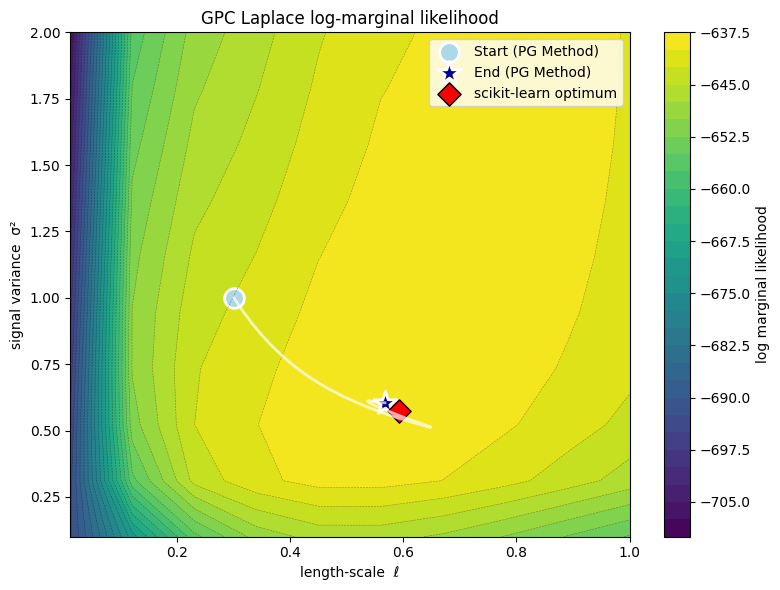

scikit‑learn optimum:
  σ² = 0.5746
  ℓ  = 0.5922  (mean over 2 dims)


In [27]:

    # --- plot -------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6))
    cf = ax.contourf(ls_grid, var_grid, log_lml, 30, cmap="viridis")
    ax.contour(ls_grid, var_grid, log_lml, 30, colors="k", linewidths=0.4, alpha=0.4)
    plt.colorbar(cf, ax=ax, label="log marginal likelihood")

    # Plot optimization path from our method
    ax.plot(lengthscales, variances, 'w-', linewidth=2, alpha=0.7)

    # Mark the starting point
    ax.scatter(lengthscales[0], variances[0],
            color='lightblue',
            marker='o',
            s=200,
            label='Start (PG Method)',
            edgecolor='white',
            linewidth=2)

    # Mark the ending point
    ax.scatter(lengthscales[-1], variances[-1],
            color='darkblue',
            marker='*',
            s=300,
            label='End (PG Method)',
            edgecolor='white',
            linewidth=2)

    ax.scatter(ls_opt, var_opt, marker="D", s=140, c="red",
            label="scikit‑learn optimum", edgecolors="black")
    ax.set_xlabel("length‑scale  ℓ")
    ax.set_ylabel("signal variance  σ²")
    ax.set_title("GPC Laplace log‑marginal likelihood")
    ax.legend()
    plt.tight_layout();  plt.show()

    print("scikit‑learn optimum:")
    print(f"  σ² = {var_opt:.4f}")
    print(f"  ℓ  = {ls_opt:.4f}  (mean over {d} dims)")
